---
title: Week 6 Tutorial 3, Carbonate Buffer System
subtitle: Orchestra Scenario, Carbonate buffer system
author:
  - name: Timo Heimovaara
    affiliations: Delft University of Technology, department of Geoscience & Engineering
    orcid: 
    email: t.j.heimovaara@tudelft.nl
license: CC-BY-NC-ND-4.0 (https://creativecommons.org/licenses/by-nc-nd/4.0/).
date: 2026-01-07
kernelspec:
    name: python3
    display_name: 'Python 3.13'
---

## Orchestra as a tool
This example illustrates how to use Python and ORCHESTRA to simulate the Carbonate-Buffer in water.

The next python cells imports the necessary libararies and checks the path to the input files required for the Orchestra simulation. Please note that this is only required for the jupyter-book version. For a stand-alone version of this notebook you need to start jupyter-lab from the directory with the input files.

In [4]:
# Import libraries required for running all simulations
import os
import sys
from IPython.utils import capture
from IPython.display import display, Markdown
from pathlib import Path
from contextlib import chdir

import numpy as np
import matplotlib.pyplot as plt
import PyORCHESTRA # here, the ORCHESTRA submodule is imported
import pandas as pd
import seaborn as sns

%matplotlib widget
sns.set()

# Prepare a file to capture PyOrchestra output
capture_file = open("pyorchestra_output.log", "w")


# pyOrchestra is implemented in C++
# Save original stdout file descriptor
original_stdout_fd = sys.stdout.fileno()

# Duplicate original stdout so we can restore it later
saved_stdout_fd = os.dup(original_stdout_fd)



# We need to import some Orchestra files. We need to know the path layout on 
# the local machine:
def find_book_root(start: Path | None = None) -> Path:
    """
    Walk upward from `start` (or CWD) until a directory containing Jupyter Book
    marker files is found. Returns the path to the book root.
    Raises FileNotFoundError if no root is found.
    """
    config_any = {"_config.yml", "_config.yaml"}      # some projectrs use .yaml
    myst_any = {"myst.yml", "myst.yaml"}            # jupyter-book uses _toc.yml

    cur = Path(Path.cwd()).resolve()

    for parent in [cur, *cur.parents]:
        children = {f.name for f in parent.iterdir()} if parent.exists() else set()
        has_any_config = bool(config_any & children)
        has_any_myst = bool(myst_any & children)
        if has_any_config and has_any_myst:
            return parent

    raise FileNotFoundError(
        f"Could not find Jupyter Book root (no _config.y* and myst.y* found above {cur})"
    )


def path_from_book_root(*parts: str | Path) -> Path:
    root = find_book_root()
    p = (root.joinpath(*parts)).resolve()
    if not p.exists():
        raise FileNotFoundError(f"Path not found: {p}")
    return p

# In order for orchestra to run we need to change directory to the directory with the input file:


# Example usage:
# input_file = path_from_book_root("content", "week 02", "Orchestra_simulation", "chemistry1.inp")
# print("Input file:", input_file)
   
orchestra_path = path_from_book_root("content", "week 4.2", "Week 4.2_Tutorial-2-ChemicalBuffersSystems_sulfurous_acid")
# print(orchestra_path)

## Download this script and the required ORCHESTRA files
TODO Create an yml for a local python environment
TODO Create zip file with the correct files. Explain how to install Orchestra using pip in a local python environment.
TODO Update all files so that they are well documented and describe the system

pyorchestra will be initialize with the correct chemistry file...

explain that InVars are the species used to define the totals. 
explain that OutVars is the list of Orchestra variables that are exported to python for post-processing or necessary for simulation.

Once prinicple problem is known we can create and initialize a pyorchestra object.

## Define chemical system: Sulfurous Acid, and Water using the ORCHESTRA-GUI

Using all insights from above we generated the following master species table: 

|Primary entity|Phase|Input Variable|Fix log activity|Log activity|Concentration|Phase|Expression|
|--|--|--|--|--|--|--|--|
|Ar[g]|gas||x|0||||
|Cl-|diss||||1.0e-9|tot||
|H+|diss|pH|x|7.0|||H.logact=-pH|
|H2O|liter||x|-0.0||||
|Na+|diss||||0.2|tot||
|SO3-2|diss||||0.1|tot||

Orchestra will use these primary entities, and their initial values to calculate the total elemental composition in the complete system. The fixed log-activties indicate that the total can vary during the simulation, as long as the log-activity condition is maintained or because Orchestra uses these values to balance the charge of the solution (Na+.tot and Cl-.tot). 

### Phases & Reactions
On the **Phases & Reactions** tab shown in figure [](#phases_reactions) we define the reaction network of our system. Please ensure that all reactions are marked.

### Other tabs
There is no need to change anything on the other tabs as these are correctly set in Tutorial 1.
There is however one thing that you need to check before we can proceed which is the way ORCHESTRA calculates the pressure in the gas phase. This cannot be done with the GUI, but has to done by adding (or unmarking) code in the *chemistry.inp* file itself. This is the reason why we now use *chemistry_fixedVolume.inp* instead of *chemistry1.inp* because we have changed line 68 to
```{code}
@Calc: (5,  "pressure = {CO2[g].con} + {Ar[g].con}")     // is total fluid volume in cell
```
allowing ORCHESTRA to calculate the total pressure as the sum of the partial pressures of the gaseous species defined by us.

For a fixed-pressure problem we need to change this file in a different way as is done in *chemistry_fixedPressure.inp*.

### Using Orchestra to run the scenario
It is possible to use the ORCHESTRA GUI to run the simulation, and this has been prepared using the **Input** and **Output** tabs on the right of the window. Please have look at these tabs and they should be rather "self explanatory". 



## Running the Sulfurous Acid-Water scenario in a Python notebook

We follow the same systematic approach as Tutorial 1, which consists of the following standard steps:
1. define the domain for our problem
2. define the primary species which change during our scenario
3. initialize the problem
4. run the problem
5. process the output

### 1. Define the domain
For our analysis we choose to work with a system containing 1 liter of water and 1 liter of gas phase. The volume of the solid phase is small with respect the total volume and will be neglected for now.

### 2. Define the primary species
The primary species are as defined above with the ORCHESTRA GUI. Please note that the values required by ORCHESTRA have to be in moles. In order to get moles/liter the volume of water has to be set to 1 liter, and the density of water need to be given as well.

### 3. Initialise the problem 
The initial condition for our problem will be defined by setting the amounts of $\text{SO}_3^{-2}$ and $\text{Na}^+$ in our system. 

Once pyOrchestra is initialized, running a simulation consists of a series of steps where the values of the required set of input variables are passed via *InVARS* to ORCHESTRA, after which a set of corresponding output variables are passed back in *OutVars*.

ORCHESTRA is initialized in pyOrchestra using the inputfile *chemistry_sulfurous_acid_buffer.inp*, created above with the ORCHESTRA-GUI. After initialization in Python, we know which variables will be passed through *OutVars* and can be used in *InVars*.

The following code shows how to do this.
```{note} 
It is relatively easy to change the OutVars array. In order to find all possible variables in ORCHESTRA, check the **Phases & Reactions** tab on the **Chemistry** tab in the ORCHESTRA-GUI .
```


In [5]:
#--- Initialize problem --- 
# for initialization we need to temporarily move to the directory containing the 'chemistry1.inp' file.
with chdir(orchestra_path):

    # Input file is generated with Orchestra GUI
    InputFile = 'chemistry_sulfurous_acid_buffer.inp'
    NoCells = 1 #only 1 cell to have a 0-D system with 1liter of water
    
    # We define the input variables that will be changed in the script
    InVars = np.array(['pH',
                       'Na+.tot', 
                       'SO3-2.tot',
                       'Cl-.tot',
                       'watervolume',
                       'gasvolume'
                       'gastype'
                       ])
    
    # We select the output from Orchestra we need to use
    OutVars = np.array(['pH', 'H+.con', 'H+.tot', 'H+.logact',
                        'OH-.tot', 'OH-.con', 'OH-.logact',
                        'SO3-2.tot', 'SO3-2.con', 'SO3-2.diss', 'SO3-2.logact',
                        'H[SO3]-.tot', 'H[SO3]-.con', 'H[SO3]-.diss', 'H[SO3]-.logact',
                        'H2[SO3].tot', 'H2[SO3].con', 'H2[SO3].diss', 'H2[SO3].logact',
                        'SO2.tot', 'SO2.con', 'SO2.diss', 'SO2.logact',
                        'Cl-.tot', 'Cl-.con', 'Cl-.logact', 'Cl-.diss', 
                        'Na+.tot', 'Na+.con', 'Na+.logact', 'Na+.diss',
                        'I', 'chargebalance', 'watervolume', 'gasvolume','pressure' ])

    # Associate a variable with the pyOrchestra.ORCHESTRA() class
    p = PyORCHESTRA.ORCHESTRA()

    # Initialize the class with the parameters defined above
    p.initialise(InputFile, NoCells, InVars, OutVars)


Reading and expanding calculator new stylechemistry_sulfurous_acid_buffer.inp
Scanning file: chemistry_sulfurous_acid_buffer.inp
Including file: objects2025.txt
Scanning file: chemistry_sulfurous_acid_buffer.inp
Including file: objects2025.txt
Including file: chemistry_sulfurous_acid_buffer.inp
Including file: objects2025.txt
0.066 sec.
	Reading variables .... 0.012 s
testing:
10:pH
12:Na+.tot
14:SO3-2.tot
9:Cl-.tot
15:watervolume
16:gasvolumegastype
10:pH
17:H+.con
18:H+.tot
19:H+.logact
20:OH-.tot
21:OH-.con
22:OH-.logact
14:SO3-2.tot
23:SO3-2.con
24:SO3-2.diss
13:SO3-2.logact
25:H[SO3]-.tot
26:H[SO3]-.con
27:H[SO3]-.diss
28:H[SO3]-.logact
29:H2[SO3].tot
30:H2[SO3].con
31:H2[SO3].diss
32:H2[SO3].logact
33:SO2.tot
34:SO2.con
35:SO2.diss
36:SO2.logact
9:Cl-.tot
37:Cl-.con
8:Cl-.logact
38:Cl-.diss
12:Na+.tot
39:Na+.con
11:Na+.logact
40:Na+.diss
3:I
6:chargebalance
15:watervolume
41:gasvolume
42:pressure
Initialise Completed! the following IO parameters will be used:
0 : Node_ID : 0
1 : 

In [6]:
orchestra_path

PosixPath('/home/theimovaara/BackupTHe/GitHub/oit_chemistry_for_earth_sciences/chemistry_book/content/week 4.2/Week 4.2_Tutorial-2-ChemicalBuffersSystems_sulfurous_acid')

Please note that the output of this code is what ORCHESTRA echos back. ORCHESTRA uses a set of variables in order to store the input variables and the results of the calculations, in this case 33. The top part of the output shows the output requested by us through *OutVars* together with the values used during initialization.

### Run the Problem
The aim of the scenario for now is to see if we can replicate a similar graph as figure 4.1 of Appelo and Postma.

:::{figure} images/Appelo&Postma_fig5.5.png
:name: appelo_fig5_5
:align: center
:width: 75%
Appelo & Postma figure 5.5
:::

In our simulation we control the total amount of carbonate in the system with CO2[g].tot, if we require carbonate in a mineral phase we can add this by defining the total amount of Ca+2.tot in the system, the system will allow Calcite (and other Calcium carbonate minerals to precipitate). As the pH in the figure ranges from 3 to 13 we choose to have pH as the "driving" variable for our scenario.
Finally the total amount of Carbonate in the system is not really relevant as the graph shows a percentage of $\text{HCO}_3^-$, we choose to set CO2[g].tot to 1 mmol in this system.

### Step 1: Define the default InVars

In [15]:
# %%
# Step 1, initial condition.
# InVars need to contain floats
IN = np.array([np.ones_like(InVars)]).astype(float)

# Define initial conditions
SO32_ini = 0.1 #0.3 # moles
Na_ini = 0.2 # moles This implies that we have added 0.1 mol/l Na2SO3 

IN[0][np.where(InVars == 'SO3-2.tot')] = SO32_ini # moles
IN[0][np.where(InVars == 'Na+.tot')] = Na_ini # No Gypsum (initial conditions)
IN[0][np.where(InVars == 'Cl-.tot')] = 1e-20 # No Chloride (initial conditions)
IN[0][np.where(InVars == 'watervolume')] = 1.0 # 1 liter
IN[0][np.where(InVars == 'gasvolume')] = 1.0 # 1 liter

# Calculate equilibrium conditions for initial situation 
OUT = p.set_and_calculate(IN)
Res_initial = pd.DataFrame(OUT,columns=OutVars)
print(Res_initial.T)

                           0
pH              9.795747e+00
H+.con          2.181922e-10
H+.tot          3.866771e-15
H+.logact      -9.795747e+00
OH-.tot         9.335039e-05
OH-.con         9.335039e-05
OH-.logact     -4.201278e+00
SO3-2.tot       1.000000e-01
SO3-2.con       9.990665e-02
SO3-2.diss      1.000000e-01
SO3-2.logact   -1.538750e+00
H[SO3]-.tot     9.334912e-05
H[SO3]-.con     9.334912e-05
H[SO3]-.diss    9.334912e-05
H[SO3]-.logact -4.164476e+00
H2[SO3].tot     7.939166e-13
H2[SO3].con     7.939166e-13
H2[SO3].diss    7.939166e-13
H2[SO3].logact -1.210023e+01
SO2.tot         7.939166e-13
SO2.con         7.939166e-13
SO2.diss        7.939166e-13
SO2.logact     -1.210023e+01
Cl-.tot         1.000000e-20
Cl-.con         5.464179e-14
Cl-.logact     -1.339706e+01
Cl-.diss        5.464179e-14
Na+.tot         2.000000e-01
Na+.con         2.000000e-01
Na+.logact     -8.335561e-01
Na+.diss        2.000000e-01
I               2.999066e-01
chargebalance   0.000000e+00
watervolume   

### Step 2: Simulate the addition of a strong acid (HCl)
We add acid by adding Cl- in small increments. H+ is added implicitly as we allow Orchestra to balance charge using the pH.

In [20]:
# Define the incremental pH change

Cl_range = np.logspace(-5, 0, 101)

#  Prepare an array to store all results from our scenario
all_Res = np.zeros([len(Cl_range),len(OutVars)])

# loop over pH_Range 
# we use a counter ii in order to store the results
ii = -1
for Cl in Cl_range:
    
    IN[0][np.where(InVars == 'Cl-.tot')] = Cl

    # run ORCHESTRA
    OUT = p.set_and_calculate(IN)
    ii = ii + 1
    all_Res[ii] = OUT[0]

    # Create a dataframe from all_Res
Res_Simulation = pd.DataFrame(all_Res,columns=OutVars)

chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying better start estimations was successful!!
chemistry_sulfurous_acid_buffer.inp: Improving start estimations:.
&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&|
Trying

## Process Output
To process the output we first generate a similar figure as from Appelo and Postma. 
We need to calculate the percentage of $\text{HCO}_3^-$, which is quite easy as this is the ratio of HCO3-.diss/CO3-2.diss

In [21]:
Res_Simulation[['pH','Cl-.tot']]


,pH,Cl-.tot
0,9.772486,0.000010
1,9.769650,0.000011
2,9.766471,0.000013
3,9.762904,0.000014
4,9.758906,0.000016
...,...,...
96,0.491840,0.630957
97,0.416759,0.707946
98,0.343211,0.794328
99,0.270511,0.891251


Text(0, 0.5, 'pH')

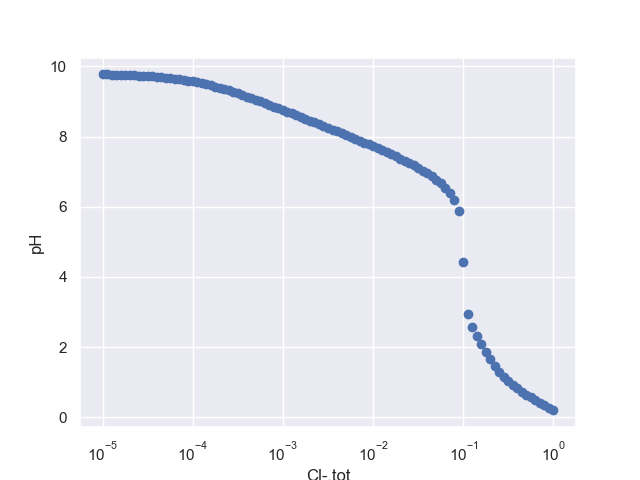

In [22]:
# Process output
# we can easily make the plot 
fig1,ax1 = plt.subplots()
# sns.scatterplot(data = Res_Simulation[['Cl-.tot','pH']],x = 'Cl-.tot', y='pH', ax=ax1)
ax1.plot(Res_Simulation['Cl-.tot'],Res_Simulation['pH'],'o')
ax1.grid(True)
ax1.set_xscale('log')
ax1.set_xlabel('Cl-.tot')
ax1.set_ylabel(r'pH')


If we compare our figure with figure 5.5 from Appelo and Postma we see that it is nearly identical. 

### Plot the Actvitiy diagram for a closed system
We now would like to create a plot similar to figure 5.7 from Appelo and Postma:
:::{figure} images/Appelo&Postma_fig5.7.png
:name: appelo_fig5_7
:align: center
:width: 75%
Appelo & Postma figure 5.7
:::

(0.0, 14.0)

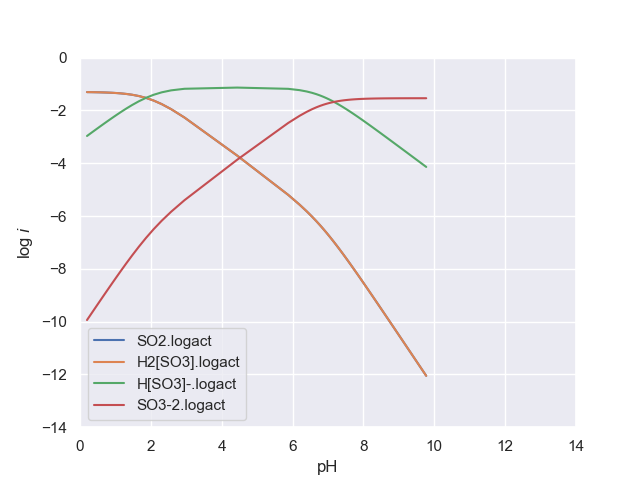

In [23]:
fig2,ax2 = plt.subplots()
species_list = ['SO2.logact','H2[SO3].logact', 'H[SO3]-.logact','SO3-2.logact']
for species in species_list:
    ax2.plot(Res_Simulation['pH'], Res_Simulation[species], '-')
ax2.grid(True)
ax2.legend(species_list)
ax2.set_xlabel('pH')
ax2.set_ylabel(r'log $i$')
ax2.set_ylim(-14,0)
ax2.set_xlim(0,14)

``` {exercise}
Explain the concentration behavior of $\text{Cl}^-$ and $\text{Na}^+$. Please note that the experiment was run by changing the pH, while keeping the total of the calcium and carbonate species constant.
```